# Trabajo Final - Curso: Aprendizaje Automático 
Maestría en Ciencia de Datos - UCU  
Equipo: Enrique De Martini, Esteban Cardoso, Lucas Barrios  

In [1]:
import pandas as pd
import numpy as np
import os

## Importar los datasets 
Los dataset son los resultados de la encuesta Aristas 2022 que se realizó a estudiantes de tercer grado de educación media.

#### Dataset de Contexto Socioeconómico

In [2]:
df_contexto = pd.read_csv(r'https://www.ineed.edu.uy/wp-content/uploads/2023/08/Datos_Estudiante_CXTO.csv',  sep=";",
    encoding="cp1252")

df_contexto = df_contexto.query('IND_CXTO == 1')
df_contexto.describe()


,AlumnoCodigoDes,GrupoCodigoDes,CentroCodigoDes,EDAD,Concurre_cod,INSE,NEE,EF1m,EF2a_1,EF2a_2,...,EF66,EF67_1,EF67_2,EF67_3,EF67_4,EEYT2,EF68,EF69,EF70,IND_CXTO
count,1.024300e+04,1.024300e+04,10243.000000,10066.000000,9978.000000,10215.000000,10243.000000,10243.000000,10243.000000,10243.000000,...,10243.000000,10243.000000,10243.000000,10243.000000,10243.000000,10243.000000,10243.000000,10243.000000,10243.000000,10243.0
mean,5.590273e+06,3.069385e+06,48660.992190,14.859626,1.072159,43.832501,0.060529,1.578737,1.206482,1.268086,...,82.076247,4.023724,3.951674,4.400078,4.058967,3.873767,3.529435,38.907547,3.550522,1.0
std,4.942643e+06,1.807796e+05,5171.166732,0.975642,0.287741,14.213884,0.238476,2.221771,2.516695,2.589010,...,33.609407,13.266114,13.281913,13.216294,13.311730,13.321083,13.516174,46.145965,13.615628,0.0
min,1.343000e+03,2.900081e+06,40392.000000,13.000000,1.000000,7.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
25%,2.362218e+06,2.954923e+06,45109.500000,14.000000,1.000000,33.000000,0.000000,1.000000,1.000000,1.000000,...,96.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.0
50%,3.890586e+06,3.000823e+06,47957.000000,15.000000,1.000000,42.000000,0.000000,2.000000,1.000000,1.000000,...,96.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.0
75%,5.521226e+06,3.065015e+06,50643.000000,15.000000,1.000000,53.000000,0.000000,2.000000,1.000000,1.000000,...,96.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,96.000000,2.000000,1.0
max,1.588363e+07,3.435836e+06,62288.000000,43.000000,3.000000,88.000000,1.000000,99.000000,99.000000,99.000000,...,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,1.0


#### Dataset de Habilidades Socioemcionales

In [3]:
df_socioemocional = pd.read_csv(r'https://www.ineed.edu.uy/wp-content/uploads/2023/08/Datos_Estudiante_Socioemocional.csv',  sep=";",
    encoding="cp1252")

df_socioemocional = df_socioemocional.query('IND_Socioemocional == 1')
df_socioemocional.describe()

,AlumnoCodigoDes,GrupoCodigoDes,CentroCodigoDes,EDAD,Concurre_cod,INSE,NEE,ES1_1,ES1_2,ES1_3,...,ECD1_7,ECD1_8,ECD1_9,ECD1_10,ECD1_11,ECD1_12,ECD2_1,ECD2_2,ECD2_3,IND_Socioemocional
count,1.039500e+04,1.039500e+04,10395.000000,9980.000000,10113.000000,9113.000000,10395.000000,10395.000000,10395.000000,10395.000000,...,10395.000000,10395.000000,10395.000000,10395.000000,10395.000000,10395.000000,10395.000000,10395.000000,10395.000000,10395.0
mean,5.585273e+06,3.069968e+06,48694.656085,14.852204,1.075151,44.408537,0.059548,2.552381,2.460510,2.362674,...,3.032131,3.604618,4.624435,3.999808,4.407888,3.113516,3.317172,2.855026,2.919577,1.0
std,4.947582e+06,1.813089e+05,5179.962768,0.952578,0.297485,14.202018,0.236659,1.891522,1.920604,1.919556,...,10.463242,12.448080,15.789528,13.840038,15.151917,10.451000,10.669449,11.896791,12.982273,0.0
min,1.343000e+03,2.900081e+06,40392.000000,13.000000,1.000000,7.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
25%,2.320866e+06,2.954957e+06,45118.000000,14.000000,1.000000,34.000000,0.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.0
50%,3.898763e+06,3.000364e+06,48042.000000,15.000000,1.000000,43.000000,0.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.0
75%,5.520368e+06,3.065032e+06,50643.000000,15.000000,1.000000,54.000000,0.000000,3.000000,3.000000,3.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,1.000000,1.0
max,1.588344e+07,3.435836e+06,62288.000000,43.000000,3.000000,88.000000,1.000000,99.000000,99.000000,99.000000,...,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,1.0


### Merge de los dos dataframes

#### Merge según _AlumnoCodigoDes_

In [4]:

# Se eliminan missing values (NaN) en las columnas específicas
df_contexto_limpio = df_contexto.dropna(subset=['Niveles_MAT'])
df_socioemocional_limpio = df_socioemocional.dropna(subset=['Niveles_MAT'])


# Columna indentificadora para hacer el merge
identificador = 'AlumnoCodigoDes'

# Averiguamos qué columnas repetidas hay en los dos dataframes para que no queden ducplicadas en el merge
cols_repetidas = [col for col in df_socioemocional_limpio.columns if col in df_contexto_limpio.columns and col != identificador]

# Eliminamos esas columnas repetidas y hacemos el merge
df_merged = df_contexto_limpio.merge(df_socioemocional_limpio.drop(columns=cols_repetidas), on=identificador, how='inner')

# Se elimina la columna EF10_otro ya que es de llenado manual y puede generar problemas a la hora de la conversion de tipos de datos de object a float
df_merged = df_merged.drop('EF10_otro', axis=1)

#### Conversion de objects a floats

In [5]:
# Se realiza la conversión de las columnas de tipo object a float, reemplazando las comas por puntos y manejando los errores de conversión:

# Seleccionamos automáticamente solo las columnas que son de tipo texto/object
columnas_texto = df_merged.select_dtypes(include=['object']).columns

for col in columnas_texto:
    # Como sabemos que son texto, podemos reemplazar las comas por puntos sin miedo
    df_merged[col] = df_merged[col].str.replace(',', '.')
    
    # Intentamos convertirlas a números. 
    # Usamos errors='ignore' para que si la columna era realmente de texto (ej: nombres de ciudades), 
    # la deje tranquila como texto y no la rompa.
    df_merged[col] = pd.to_numeric(df_merged[col], errors='ignore')

/var/folders/0m/rbf8dr3s1_g2h0t7g9scdbsr0000gn/T/ipykernel_13021/496706323.py:13: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_merged[col] = pd.to_numeric(df_merged[col], errors='ignore')


#### Resumen de la auditoria

In [6]:
# Se realiza un resumen de auditoría de los datos.
resumen_auditoria = pd.DataFrame({
    'Tipo_de_Dato': df_merged.dtypes,
    'Valores_Faltantes': df_merged.isnull().sum(),
    # Calculamos la Serie numérica y luego mapeamos el formato de string a cada fila
    'Porcentaje_de_Nulos': ((df_merged.isnull().sum() / len(df_merged)) * 100).map('{:.2f}%'.format),
    'Valores_Unicos': df_merged.nunique(),
    'Moda': df_merged.mode().iloc[0]      
})


# Mostramos la tabla resumen
print(f"Total de filas (Estudiantes que contestaron ambos cuestionarios y que realizaron la prueba de matemática): {df_merged.shape[0]}")
resumen_auditoria

Total de filas (Estudiantes que contestaron ambos cuestionarios y que realizaron la prueba de matemática): 8406


,Tipo_de_Dato,Valores_Faltantes,Porcentaje_de_Nulos,Valores_Unicos,Moda
AlumnoCodigoDes,int64,0,0.00%,8406,1360
GrupoCodigoDes,int64,0,0.00%,611,3434357.0
CentroCodigoDes,int64,0,0.00%,339,60962.0
MdeoInt,object,0,0.00%,2,Interior
regiones,object,0,0.00%,5,SUR
...,...,...,...,...,...
MOTINT_E_ESC50,float64,9,0.11%,591,45.096011
PERSAC_E_ESC50,float64,10,0.12%,1398,50.311376
REGEMO_E_ESC50,float64,18,0.21%,1877,54.561106
VALTIDE_E_ESC50,float64,7,0.08%,541,50.561581


## Eleccion de Variables

#### Diccionario

In [7]:
# Renombrar las variables que nos interesa 

nombres_legibles = {

    # --- Target ---
    'Niveles_MAT'           : 'Niveles_Matemática',

    # --- Pesos muestrales ---
    'peso_MEst'             : 'w_estudiante',

    # --- Características Comunes (Categóricas) ---
    'MdeoInt'           : 'Montevideo_o_Interior',
    'regiones'          : 'Región',                     # SUR, OESTE, NORTE, ESTE, CENTRO
    'EF46m'             : 'Departamento_residencia',
    'categoria_centro'  : 'Tipo_centro_educativo',      # Secundaria pública, Secundaria privada, UTU (escuela técnica)
    'AlumnoGenero'      : 'Género',
    'EF2d'              : 'Ascendencia', 
    'EF2b'              : 'Pais_de_Nacimiento',
    
    # --- Características Comunes (Numéricas) ---
    'EDAD': 'Edad',
    
    # --- Índices Comunes (Estatus Económico y Social) ---
    'INSE'          : 'Ind_Socioeconómico',
    'ESCS_Alumno'   : 'ESCS_Alumno',
    'ESCS_Centro'   : 'ESCS_Centro',
    'ESCS_Grupo'    : 'ESCS_Grupo',
    
    # --- Índices de Contexto ---
    'ESTSENTPER_E_ESC50'    : 'Ind_Sentido_de_Pertenencia',
    'VINCENTREEST_E_ESC50'  : 'Ind_Vínculo_entre_Estudiantes',
    'VINESTADS_E_ESC50'     : 'Ind_Vínculo_con_Adscriptos',
    'VINESTPROF_E_ESC50'    : 'Ind_Vínculo_con_Profesores',
    'VOZESTU_E_ESC50'       : 'Ind_Voz_Estudiantil',
    'ACTITUDLEC_E_ESC50'    : 'Ind_Actitud_hacia_la_Lectura',
    'ACTITUDMAT_E_ESC50'    : 'Ind_Actitud_hacia_la_Matemática',
    
    # --- Índices de Habilidades Socioemocionales ---
    'AUTOCON_E_ESC50'       : 'Ind_de_Autocontrol',
    'AUTOEIDE_E_ESC50'      : 'Ind_de_Autoeficacia_académica_en_Idioma_Español',
    'AUTOEMAT_E_ESC50'      : 'Ind_de_Autoeficacia_académica_en_Matemática',
    'AUTOMETA_E_ESC50'      : 'Ind_de_Autorregulación_metacognitiva',
    'EMPATIA_E_ESC50'       : 'Ind_de_Empatía',
    'EXTERNALIZ_E_ESC50'    : 'Ind_de_Conductas_externalizantes',
    'HABINTER_E_ESC50'      : 'Ind_de_Habilidades_interpersonales',
    'HABINTRA_E_ESC50'      : 'Ind_de_Habilidades_intrapersonales',
    'HABRELAC_E_ESC50'      : 'Ind_de_Habilidades_de_relacionamiento',
    'INTERNALIZ_E_ESC50'    : 'Ind_de_Conductas_internalizantes',
    'MOTAUTREGA_E_ESC50'    : 'Ind_de_Motivación_y_autorregulación_del_aprendizaje',
    'MOTINT_E_ESC50'        : 'Ind_de_Motivación_intrínseca',
    'PERSAC_E_ESC50'        : 'Ind_de_Perseverancia_académica',
    'REGEMO_E_ESC50'        : 'Ind_de_Regulación_emocional',
    'VALTIDE_E_ESC50'       : 'Ind_de_Valoración_de_la_tarea_en_Idioma_Español',
    'VALTMAT_E_ESC50'       : 'Ind_de_Valoración_de_la_tarea_en_Matemática'
}

#### Filtrado de las variables y binarizacion del Target 

In [8]:
# Filtrar y renombrar en un solo paso
df_procesado = df_merged[list(nombres_legibles.keys())].rename(columns=nombres_legibles)

# X de variables predictoras
X = df_procesado.drop(columns=['w_estudiante', 'Niveles_Matemática'])   # Características
# quitar los no se/no responde
X = X.replace({99: np.nan, 98: np.nan, "99": np.nan, "98": np.nan})
                             
w = df_procesado['w_estudiante']                                         # Pesos muestrales

# Target binario:
# 1 (satisfactorio) = N4 o N5; 0 (insatisfactorio) = B1, N1, N2 o N3
y = np.where(df_procesado["Niveles_Matemática"].isin(["N4", "N5"]), 1, 0)

## Modelado

#### Split train-test

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, 
    y, 
    w,
    test_size=0.2, 
    random_state=42,
    stratify=y 
)

#### Column Transformer

In [10]:
# 1. Variables Categóricas (Para OneHotEncoder / imputación por moda)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

variables_categoricas = [
    'Montevideo_o_Interior',
    'Región',
    'Departamento_residencia',
    'Tipo_centro_educativo',
    'Género',
    'Ascendencia',
    'Pais_de_Nacimiento'
]

# 2. Variables Numéricas e Índices (Para StandardScaler / imputación por mediana)
variables_numericas = [
    # Numérica clásica
    'Edad',
    
    # Índices (Estatus Económico y Social)
    'Ind_Socioeconómico',
    'ESCS_Alumno',
    'ESCS_Centro',
    'ESCS_Grupo',
    
    # Índices de Contexto
    'Ind_Sentido_de_Pertenencia',
    'Ind_Vínculo_entre_Estudiantes',
    'Ind_Vínculo_con_Adscriptos',
    'Ind_Vínculo_con_Profesores',
    'Ind_Voz_Estudiantil',
    'Ind_Actitud_hacia_la_Lectura',
    'Ind_Actitud_hacia_la_Matemática',
    
    # Índices de Habilidades Socioemocionales
    'Ind_de_Autocontrol',
    'Ind_de_Autoeficacia_académica_en_Idioma_Español',
    'Ind_de_Autoeficacia_académica_en_Matemática',
    'Ind_de_Autorregulación_metacognitiva',
    'Ind_de_Empatía',
    'Ind_de_Conductas_externalizantes',
    'Ind_de_Habilidades_interpersonales',
    'Ind_de_Habilidades_intrapersonales',
    'Ind_de_Habilidades_de_relacionamiento',
    'Ind_de_Conductas_internalizantes',
    'Ind_de_Motivación_y_autorregulación_del_aprendizaje',
    'Ind_de_Motivación_intrínseca',
    'Ind_de_Perseverancia_académica',
    'Ind_de_Regulación_emocional',
    'Ind_de_Valoración_de_la_tarea_en_Idioma_Español',
    'Ind_de_Valoración_de_la_tarea_en_Matemática'
]

# =====================================================================
#                   Construcción del Preprocesador
# =====================================================================

# Imputación KNN para numéricas y escalado
transformador_num = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
    ("scaler", StandardScaler()),
])

# Imputación por moda y OneHot para categóricas
transformador_cat = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocesador = ColumnTransformer(transformers=[
    ("num", transformador_num, variables_numericas),
    ("cat", transformador_cat, variables_categoricas),
])


#### Instanciado y corrida de los 3 modelos

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# =====================================================================
#            Generación de Modelos, GridSearchCV y Ajuste
# =====================================================================

# Definir modelos a analizar
modelos = {
    "Regresion_Logistica": LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random_Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    # En XGBoost usamos scale_pos_weight en lugar de class_weight
    "XGBoost": XGBClassifier(random_state=42, eval_metric="auc", scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train))
}

# Definir grillas de hiperparámetros
param_grids = {
    "Regresion_Logistica": {
        "clasificador__C": [0.01, 0.05 ,0.1,0.2, 0.3, 0.4, 0.5,0.6, 1.0, 10.0]
    },
    "KNN": {
        "clasificador__n_neighbors": [3, 5, 7, 9],
        "clasificador__weights": ["uniform", "distance"]
    },
    "Random_Forest": {
        "clasificador__n_estimators": [100, 200],
        "clasificador__max_depth": [10, 20, None],
        "clasificador__min_samples_split": [5, 10]
    },
    "XGBoost": {
        "clasificador__n_estimators": [100, 200],
        "clasificador__max_depth": [3, 5, 7],
        "clasificador__learning_rate": [0.01, 0.1]
    }
}

cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_grid = {}

# Entrenar todos los modelos
for nombre_modelo, modelo in modelos.items():
    print(f"\nEntrenando {nombre_modelo}...")
    
    pipeline_completo = Pipeline(steps=[
        ("preprocesamiento", preprocesador),
        ("clasificador", modelo)
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline_completo,
        param_grid=param_grids[nombre_modelo],
        cv=cv_estrategia,
        scoring="roc_auc",
        n_jobs=-1,
        error_score="raise"
    )
    
    # Manejo dinámico de pesos muestrales (w_train)
    if nombre_modelo == "KNN":
        # KNN no soporta sample_weight en su método .fit()
        grid_search.fit(X_train, y_train)
    else:
        # Ajuste con pesos de encuesta para el resto de los algoritmos
        fit_params = {"clasificador__sample_weight": w_train}
        grid_search.fit(X_train, y_train, **fit_params)
    
    resultados_grid[nombre_modelo] = grid_search


Entrenando Regresion_Logistica...

Entrenando KNN...

Entrenando Random_Forest...

Entrenando XGBoost...


#### Modelo ganador

In [20]:
# =====================================================================
#                  Definición del modelo ganador
# =====================================================================

mejor_nombre = None
mejor_score = 0
mejor_grid = None

print("\n--- Comparación de Modelos (ROC-AUC en Validación Cruzada) ---")
for nombre, grid in resultados_grid.items():
    score_cv = grid.best_score_
    print(f"{nombre}: {score_cv:.4f}")
    if score_cv > mejor_score:
        mejor_score = score_cv
        mejor_nombre = nombre
        mejor_grid = grid

print(f"\nEl modelo ganador es: {mejor_nombre} con ROC-AUC de {mejor_score:.4f}")
mejor_modelo = mejor_grid.best_estimator_


--- Comparación de Modelos (ROC-AUC en Validación Cruzada) ---
Regresion_Logistica: 0.8846
KNN: 0.8288
Random_Forest: 0.8794
XGBoost: 0.8813

El modelo ganador es: Regresion_Logistica con ROC-AUC de 0.8846


## Feature importances

In [21]:
# =====================================================================
#                  Análisis de Feature Importance
# =====================================================================

print("\n--- Feature Importance del Mejor Modelo ---")
try:
    # Extraer el clasificador y los nombres de las features del preprocesador
    clasificador_entrenado = mejor_modelo.named_steps["clasificador"]
    
    # Obtener nombres de columnas categóricas luego del OneHot
    nombres_cat = mejor_modelo.named_steps["preprocesamiento"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(variables_categoricas)
    todas_las_features = variables_numericas + list(nombres_cat)
    
    if hasattr(clasificador_entrenado, "feature_importances_"):
        importancias = clasificador_entrenado.feature_importances_
    elif hasattr(clasificador_entrenado, "coef_"):
        importancias = np.abs(clasificador_entrenado.coef_[0])
        
    df_importances = pd.DataFrame({"Feature": todas_las_features, "Importancia": importancias})
    df_importances = df_importances.sort_values(by="Importancia", ascending=False).head(10)
    print(df_importances)
except Exception as e:
    print("No se pudo calcular la importancia de variables directamente. (Revisar compatibilidad del modelo).")


--- Feature Importance del Mejor Modelo ---
                                        Feature  Importancia
2                                   ESCS_Alumno     0.978588
1                            Ind_Socioeconómico     0.632360
14  Ind_de_Autoeficacia_académica_en_Matemática     0.615468
62                              Ascendencia_3.0     0.606711
3                                   ESCS_Centro     0.591946
39                  Departamento_residencia_5.0     0.579231
56                    Tipo_centro_educativo_UTU     0.535145
11              Ind_Actitud_hacia_la_Matemática     0.515109
36                  Departamento_residencia_2.0     0.505925
42                  Departamento_residencia_8.0     0.470680



--- Evaluación en Test (Ponderada) ---
Mejores hiperparámetros encontrados: {'clasificador__C': 0.1}
ROC-AUC en conjunto de Test (ponderado): 0.8598
Matriz de Confusión Ponderada (Poblacional):
[[1144.0558258   299.31276682]
 [  47.69355605  152.23341362]]


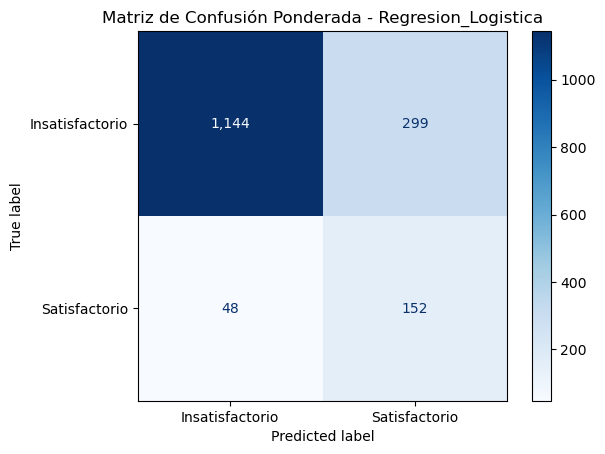

In [22]:
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
# =====================================================================
#                 Resultados y evaluación en Test
# =====================================================================

print("\n--- Evaluación en Test (Ponderada) ---")
print("Mejores hiperparámetros encontrados:", mejor_grid.best_params_)

y_pred_proba = mejor_modelo.predict_proba(X_test)[:, 1]
score_test = roc_auc_score(y_test, y_pred_proba, sample_weight=w_test)
print(f"ROC-AUC en conjunto de Test (ponderado): {score_test:.4f}")

# Generar la predicción estándar de clases
y_pred = mejor_modelo.predict(X_test)

# Calcular la matriz de confusión PONDERADA
cm_ponderada = confusion_matrix(y_test, y_pred, sample_weight=w_test)

# Configurar Numpy para evitar notación científica en el print de la consola
np.set_printoptions(suppress=True)
print("Matriz de Confusión Ponderada (Poblacional):")
print(cm_ponderada)

# Visualizarla de forma gráfica evitando notación científica
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ponderada, 
    display_labels=["Insatisfactorio", "Satisfactorio"]
)

# El parámetro values_format=',.0f' quita la notación científica y agrega separador de miles
disp.plot(cmap=plt.cm.Blues, values_format=',.0f')
plt.title(f"Matriz de Confusión Ponderada - {mejor_nombre}")
plt.show()